In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
phising_data=pd.read_csv('dataset_phishing.csv')

In [7]:
df=phising_data.copy()

In [8]:
df

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11425,http://www.fontspace.com/category/blackletter,45,17,0,2,0,0,0,0,0,...,0,0,0,448,5396,3980,0,0,6,legitimate
11426,http://www.budgetbots.com/server.php/Server%20...,84,18,0,5,0,1,1,0,0,...,1,0,0,211,6728,0,0,1,0,phishing
11427,https://www.facebook.com/Interactive-Televisio...,105,16,1,2,6,0,1,0,0,...,0,0,0,2809,8515,8,0,1,10,legitimate
11428,http://www.mypublicdomainpictures.com/,38,30,0,2,0,0,0,0,0,...,1,0,0,85,2836,2455493,0,0,4,legitimate


### Data Assessing

- no null values
- some duplicated values
- outliers in domain_age as min =-12,ratio_extRedirection max=2

In [9]:
important_features = [
    'domain_age',
    'phish_hints',
    'ratio_extHyperlinks',
    'ratio_intHyperlinks',
    'safe_anchor',
    'ratio_extRedirection',
    'length_url',
    'ratio_digits_url',
    'length_words_raw',
    'longest_words_raw',
    'length_hostname',
    'avg_word_path',
    'domain_in_title',
    'char_repeat'
]

In [10]:
selected_df = df[important_features + ['status']]

In [11]:
df=selected_df.copy()
df

,domain_age,phish_hints,ratio_extHyperlinks,ratio_intHyperlinks,safe_anchor,ratio_extRedirection,length_url,ratio_digits_url,length_words_raw,longest_words_raw,length_hostname,avg_word_path,domain_in_title,char_repeat,status
0,-1,0,0.470588,0.529412,0.000000,0.875000,37,0.000000,4,11,19,4.500000,0,4,legitimate
1,5767,0,0.033333,0.966667,100.000000,0.000000,77,0.220779,4,32,23,14.666667,1,4,phishing
2,4004,0,0.000000,1.000000,100.000000,0.000000,126,0.150794,12,17,50,8.142857,1,2,phishing
3,-1,0,0.026846,0.973154,62.500000,0.250000,18,0.000000,1,5,11,0.000000,1,0,legitimate
4,8175,0,0.529412,0.470588,0.000000,0.537037,55,0.000000,6,11,15,7.000000,0,3,legitimate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11425,5396,0,0.115578,0.884422,0.000000,0.043478,45,0.000000,4,11,17,9.500000,0,4,legitimate
11426,6728,0,0.000000,1.000000,0.000000,0.000000,84,0.023810,12,10,18,4.900000,1,3,phishing
11427,8515,0,0.529412,0.470588,80.000000,0.000000,105,0.142857,13,15,16,6.272727,0,5,legitimate
11428,2836,0,0.625000,0.375000,0.000000,0.050000,38,0.000000,2,22,30,0.000000,1,3,legitimate


In [12]:
df.shape

(11430, 15)

In [13]:
df.dtypes

domain_age                int64
phish_hints               int64
ratio_extHyperlinks     float64
ratio_intHyperlinks     float64
safe_anchor             float64
ratio_extRedirection    float64
length_url                int64
ratio_digits_url        float64
length_words_raw          int64
longest_words_raw         int64
length_hostname           int64
avg_word_path           float64
domain_in_title           int64
char_repeat               int64
status                   object
dtype: object

In [14]:
df.head()

,domain_age,phish_hints,ratio_extHyperlinks,ratio_intHyperlinks,safe_anchor,ratio_extRedirection,length_url,ratio_digits_url,length_words_raw,longest_words_raw,length_hostname,avg_word_path,domain_in_title,char_repeat,status
0,-1,0,0.470588,0.529412,0.0,0.875000,37,0.000000,4,11,19,4.500000,0,4,legitimate
1,5767,0,0.033333,0.966667,100.0,0.000000,77,0.220779,4,32,23,14.666667,1,4,phishing
2,4004,0,0.000000,1.000000,100.0,0.000000,126,0.150794,12,17,50,8.142857,1,2,phishing
3,-1,0,0.026846,0.973154,62.5,0.250000,18,0.000000,1,5,11,0.000000,1,0,legitimate
4,8175,0,0.529412,0.470588,0.0,0.537037,55,0.000000,6,11,15,7.000000,0,3,legitimate


In [15]:
df.tail()

,domain_age,phish_hints,ratio_extHyperlinks,ratio_intHyperlinks,safe_anchor,ratio_extRedirection,length_url,ratio_digits_url,length_words_raw,longest_words_raw,length_hostname,avg_word_path,domain_in_title,char_repeat,status
11425,5396,0,0.115578,0.884422,0.000000,0.043478,45,0.000000,4,11,17,9.500000,0,4,legitimate
11426,6728,0,0.000000,1.000000,0.000000,0.000000,84,0.023810,12,10,18,4.900000,1,3,phishing
11427,8515,0,0.529412,0.470588,80.000000,0.000000,105,0.142857,13,15,16,6.272727,0,5,legitimate
11428,2836,0,0.625000,0.375000,0.000000,0.050000,38,0.000000,2,22,30,0.000000,1,3,legitimate
11429,-1,3,0.571429,0.428571,33.333333,0.000000,477,0.085954,90,12,14,4.453488,1,8,phishing


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   domain_age            11430 non-null  int64  
 1   phish_hints           11430 non-null  int64  
 2   ratio_extHyperlinks   11430 non-null  float64
 3   ratio_intHyperlinks   11430 non-null  float64
 4   safe_anchor           11430 non-null  float64
 5   ratio_extRedirection  11430 non-null  float64
 6   length_url            11430 non-null  int64  
 7   ratio_digits_url      11430 non-null  float64
 8   length_words_raw      11430 non-null  int64  
 9   longest_words_raw     11430 non-null  int64  
 10  length_hostname       11430 non-null  int64  
 11  avg_word_path         11430 non-null  float64
 12  domain_in_title       11430 non-null  int64  
 13  char_repeat           11430 non-null  int64  
 14  status                11430 non-null  object 
dtypes: float64(6), int6

In [17]:
df.describe()

,domain_age,phish_hints,ratio_extHyperlinks,ratio_intHyperlinks,safe_anchor,ratio_extRedirection,length_url,ratio_digits_url,length_words_raw,longest_words_raw,length_hostname,avg_word_path,domain_in_title,char_repeat
count,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000
mean,4062.543745,0.327734,0.276720,0.602457,37.063922,0.158926,61.126684,0.053137,6.232808,15.393876,21.090289,5.092425,0.775853,2.927472
std,3107.784600,0.842600,0.319958,0.376474,39.073385,0.266437,55.297318,0.089363,5.572355,22.083644,10.777171,7.147050,0.417038,4.768936
min,-12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,1.000000,2.000000,4.000000,0.000000,0.000000,0.000000
25%,972.250000,0.000000,0.000000,0.224991,0.000000,0.000000,33.000000,0.000000,2.000000,9.000000,15.000000,0.000000,1.000000,1.000000
50%,3993.000000,0.000000,0.131148,0.743442,23.294574,0.000000,47.000000,0.000000,5.000000,11.000000,19.000000,4.857143,1.000000,3.000000
75%,7026.750000,0.000000,0.474840,0.944767,75.000000,0.230769,71.000000,0.079365,8.000000,16.000000,24.000000,6.714286,1.000000,4.000000
max,12874.000000,10.000000,1.000000,1.000000,100.000000,2.000000,1641.000000,0.723881,106.000000,829.000000,214.000000,250.000000,1.000000,146.000000


In [18]:
df.isnull().sum()

domain_age              0
phish_hints             0
ratio_extHyperlinks     0
ratio_intHyperlinks     0
safe_anchor             0
ratio_extRedirection    0
length_url              0
ratio_digits_url        0
length_words_raw        0
longest_words_raw       0
length_hostname         0
avg_word_path           0
domain_in_title         0
char_repeat             0
status                  0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(240)

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df.nunique().sort_values()

domain_in_title            2
status                     2
phish_hints                9
length_words_raw          54
char_repeat               55
length_hostname           83
longest_words_raw        119
length_url               324
avg_word_path            757
ratio_extRedirection     894
safe_anchor             1083
ratio_digits_url        1414
ratio_extHyperlinks     3131
ratio_intHyperlinks     3131
domain_age              4430
dtype: int64

In [22]:
df['domain_in_title'].unique()

array([0, 1])

In [23]:
df['status'].unique()

array(['legitimate', 'phishing'], dtype=object)

In [24]:
df['status']=df['status'].astype('category')

In [25]:
df['status'].dtype

CategoricalDtype(categories=['legitimate', 'phishing'], ordered=False, categories_dtype=object)

In [26]:
df['status'].value_counts()

status
legitimate    5714
phishing      5476
Name: count, dtype: int64

In [27]:
#in percentage
df['status'].value_counts(normalize=True)*100

status
legitimate    51.06345
phishing      48.93655
Name: proportion, dtype: float64

In [28]:
df.describe()

,domain_age,phish_hints,ratio_extHyperlinks,ratio_intHyperlinks,safe_anchor,ratio_extRedirection,length_url,ratio_digits_url,length_words_raw,longest_words_raw,length_hostname,avg_word_path,domain_in_title,char_repeat
count,11190.000000,11190.000000,11190.000000,11190.000000,11190.000000,11190.000000,11190.000000,11190.000000,11190.000000,11190.000000,11190.000000,11190.000000,11190.000000,11190.000000
mean,4060.843432,0.328061,0.274090,0.605534,37.240432,0.157181,61.212690,0.052295,6.255496,15.391957,20.981412,5.110536,0.773727,2.950849
std,3113.395697,0.841261,0.316220,0.374027,39.031255,0.263334,55.595553,0.088979,5.593800,22.223350,10.721276,7.181473,0.418437,4.782600
min,-12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,1.000000,2.000000,4.000000,0.000000,0.000000,0.000000
25%,961.250000,0.000000,0.000000,0.245312,0.000000,0.000000,33.000000,0.000000,2.000000,9.000000,15.000000,0.000000,1.000000,1.000000
50%,3993.000000,0.000000,0.132075,0.747447,25.000000,0.000000,47.000000,0.000000,5.000000,11.000000,19.000000,4.875000,1.000000,3.000000
75%,6996.000000,0.000000,0.466058,0.943802,75.000000,0.230369,71.000000,0.076923,8.000000,16.000000,24.000000,6.710714,1.000000,4.000000
max,12874.000000,10.000000,1.000000,1.000000,100.000000,2.000000,1641.000000,0.723881,106.000000,829.000000,214.000000,250.000000,1.000000,146.000000


### Checking outliers

In [29]:
df[df['domain_age']<0].value_counts()

domain_age  phish_hints  ratio_extHyperlinks  ratio_intHyperlinks  safe_anchor  ratio_extRedirection  length_url  ratio_digits_url  length_words_raw  longest_words_raw  length_hostname  avg_word_path  domain_in_title  char_repeat  status    
-12         1            0.739130             0.260870             0.000000     0.352941              40          0.000000          5                 12                 15               3.500000       1                2            phishing      1
-1          0            0.476190             0.523810             31.250000    0.350000              25          0.000000          2                 9                  17               0.000000       1                3            legitimate    1
                         0.500000             0.500000             0.000000     1.000000              43          0.232558          12                7                  13               3.625000       1                0            phishing      1
                 

In [30]:
df[df['domain_age'] < 0][['domain_age', 'status']].head()

,domain_age,status
0,-1,legitimate
3,-1,legitimate
5,-1,phishing
10,-1,legitimate
29,-1,phishing


In [31]:
(df['domain_age']<0).sum()

np.int64(1810)

In [32]:
(df['domain_age']<0).mean()*100
# 16 percent <0

np.float64(16.175156389633603)

In [33]:
df.loc[df['domain_age']<0,'domain_age']=np.nan
df['domain_age']=df['domain_age'].fillna(df['domain_age'].median())

In [34]:
df['domain_age'].describe()

count    11190.000000
mean      4881.900000
std       2552.736389
min          0.000000
25%       3014.000000
50%       5075.000000
75%       6996.000000
max      12874.000000
Name: domain_age, dtype: float64

In [35]:
(df['ratio_extRedirection']>1).value_counts()

ratio_extRedirection
False    11142
True        48
Name: count, dtype: int64

In [36]:
df['ratio_extRedirection'][df['ratio_extRedirection']>1].count()

np.int64(48)

In [37]:
(df['ratio_extRedirection']>1).mean()*100

np.float64(0.42895442359249336)

#EDA(Exploratory Data Analysis)

### Target analysis

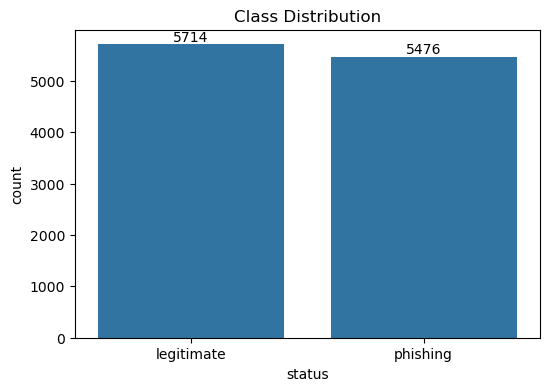

In [38]:
plt.figure(figsize=(6,4))

ax=sns.countplot(data=df,x='status')
ax.bar_label(ax.containers[0],label_type='edge')
plt.title("Class Distribution")
plt.show()

- 5714 legitimate websites and 5476 phishing websites are present
- dataset is balanced but not perfectly

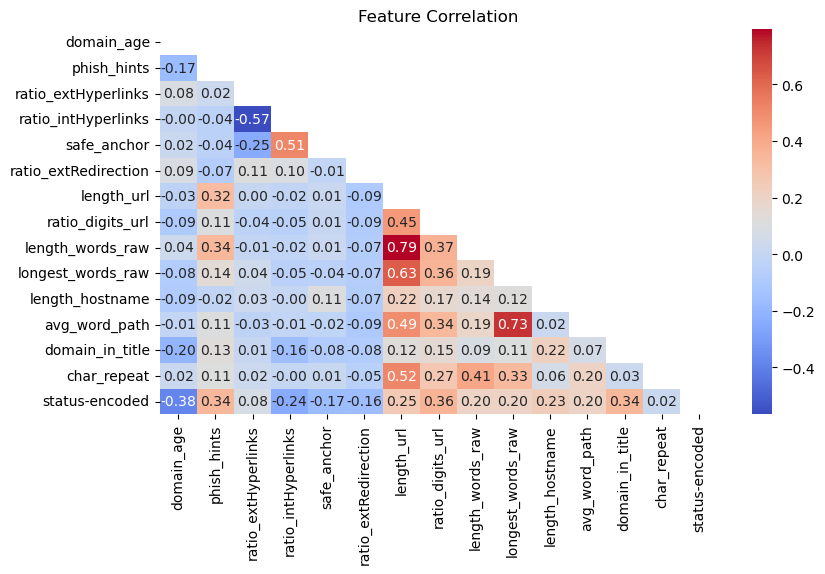

In [39]:
df['status-encoded']=df['status'].map({
    'legitimate':0,
    'phishing':1
})
df['status-encoded']=df['status-encoded'].astype('int32')
plt.figure(figsize=(9,5))
corr=df.corr(numeric_only=True)
mask=np.triu(corr)
sns.heatmap(corr,annot=True,mask=mask,fmt='0.2f',cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

- ratio_digits_url is correlated with the phising websites and have highest positive corr with phising websites
- phish_hints and domain_in_title are also highly correlated with phishing
- domain_age,ratio_intHyperlinks is negatively correlated
- yes there are highly correlated features like length_words_raw<->length_url and length_words_raw<->avg_word_path
and longest_words_raw<->length_url and they are redundant

### Distribution of Features

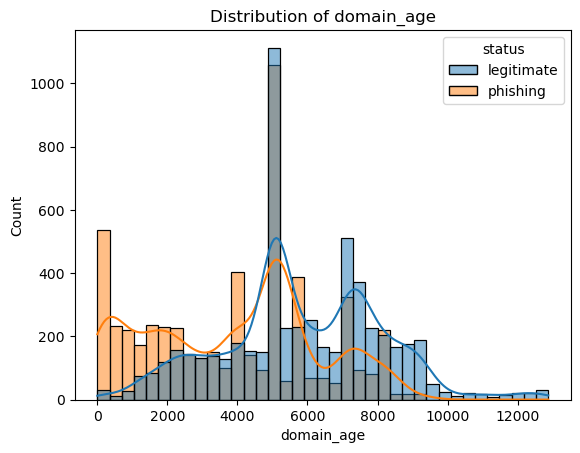

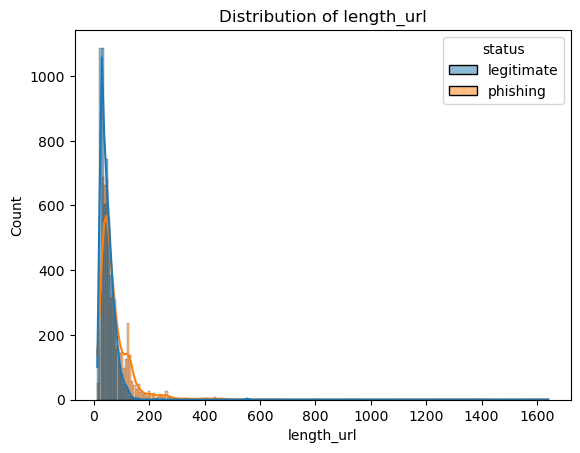

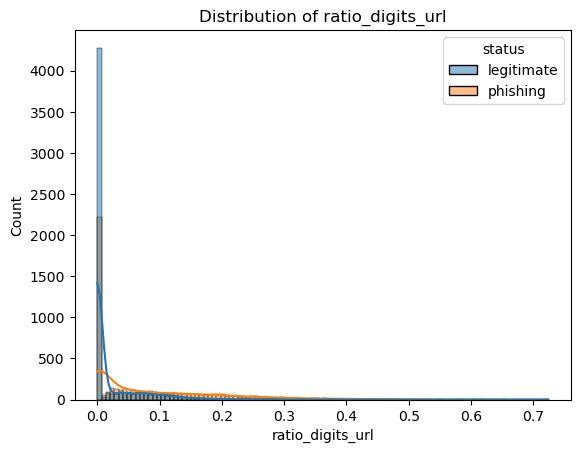

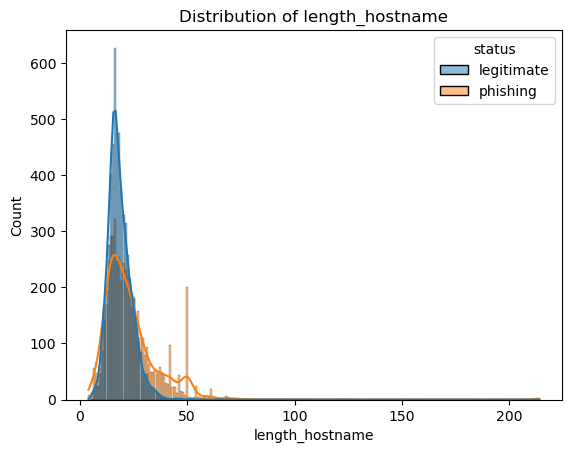

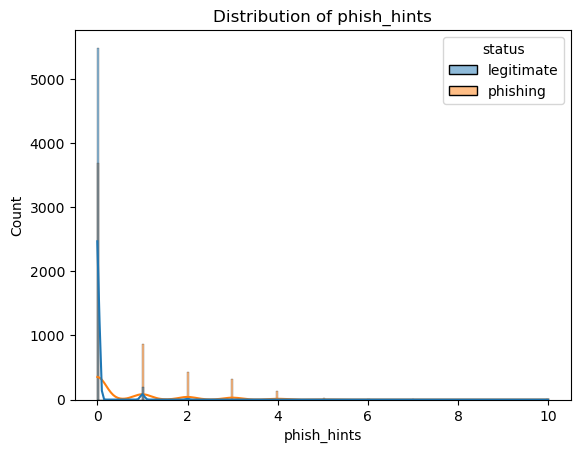

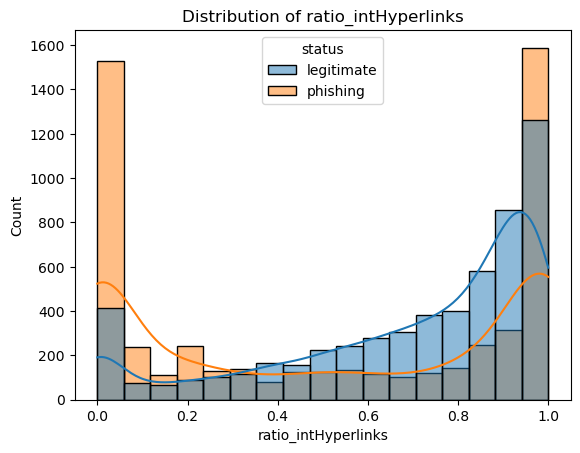

In [40]:
features = [
    'domain_age',
    'length_url',
    'ratio_digits_url',
    'length_hostname',
    'phish_hints',
    'ratio_intHyperlinks',

]

for col in features:
  sns.histplot(
      data=df,
      x=col,
      kde=True,
      hue='status'
  )
  plt.title(f"Distribution of {col}")
  plt.show()


##### Domain age distribution
- more the increase in year the more it is legitimate and in the average age has highest legitimate.
so we can say that as domain age increase,less phishing websites

##### Distribution of length_url
- less than 100 length more the legitimate
- so more the length_url more the phishing

##### Distribution of ratio_digits_url
- more the ratio more phishing

##### Distribution of length_hostname
- hostname>25 more the phishing

##### Distribution of phish_hints
- more the hints more phishing

##### Distribution of ratio_intHyperlinks
- if it is very less or very more then phishing else not



### Boxplots

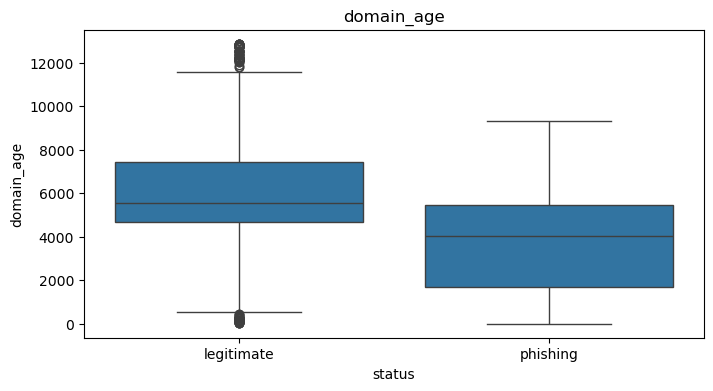

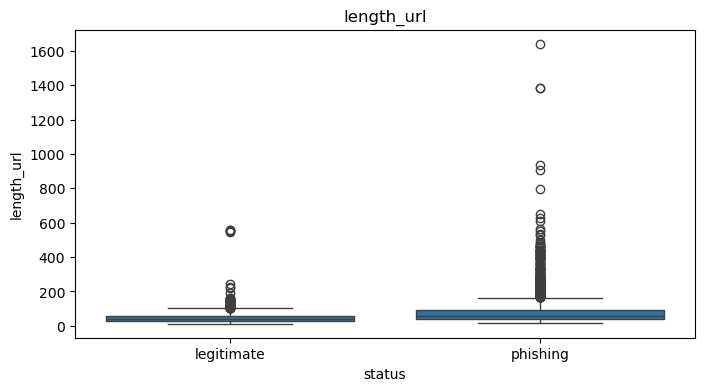

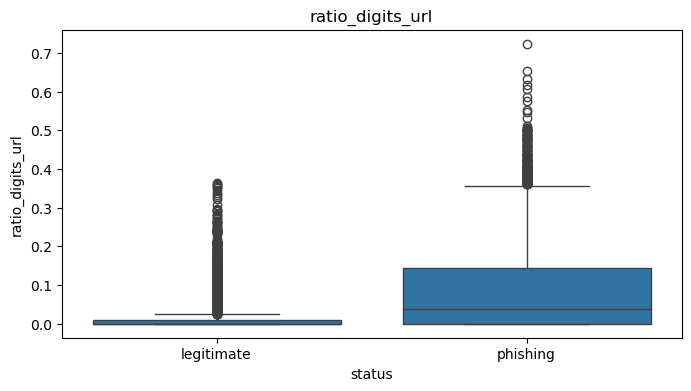

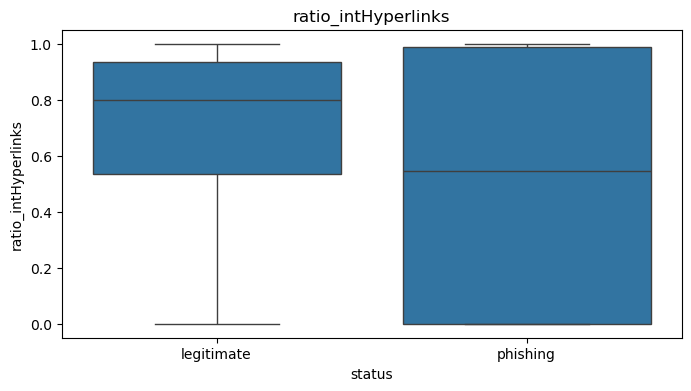

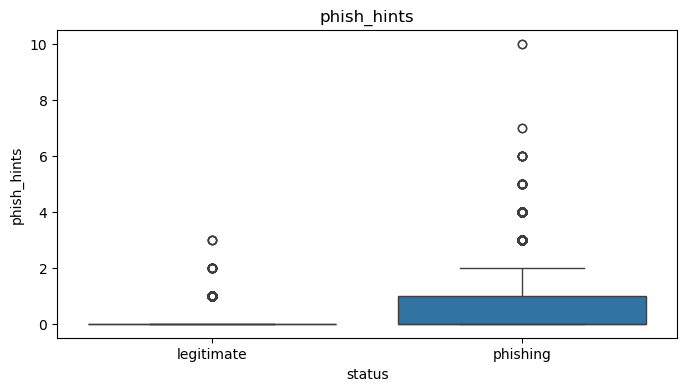

In [41]:
features = [
    'domain_age',
    'length_url',
    'ratio_digits_url',
    'ratio_intHyperlinks',
    'phish_hints'
]

for col in features:
  plt.figure(figsize=(8,4))
  sns.boxplot(data=df,x='status',y=col)
  plt.title(col)
  plt.show()

- Several features such as length_url, ratio_digits_url, and domain_age contain outliers according to boxplot analysis

- However, these outliers are likely genuine characteristics of phishing or legitimate websites rather than data errors.

- And random forest doesnot get affected much as it uses random data


### Binary Feature Analysis

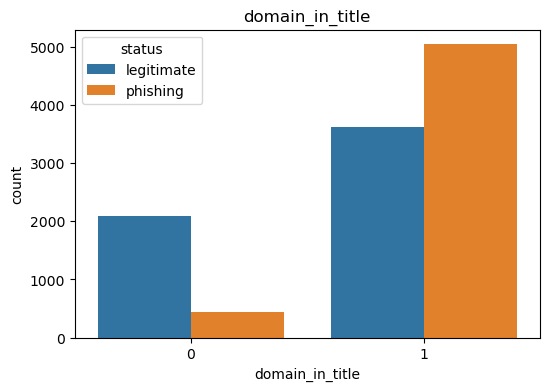

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='domain_in_title',hue='status')
plt.title('domain_in_title')
plt.show()

- Websites where the domain name does not appear in the page title (domain_in_title = 0) are predominantly legitimate websites

In [43]:
pd.crosstab(df['domain_in_title'],df['status'],normalize='index')*100

status,legitimate,phishing
domain_in_title,,
0,82.819905,17.180095
1,41.776392,58.223608


In [44]:
df.to_csv('phishing_processed.csv', index=False)